In [10]:
import cv2 

In [11]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

ee = cv2.imread('3.jpg')
ee = cv2.cvtColor(ee,cv2.COLOR_RGB2BGR)

plt.imshow(ee)
plt.show()



[ WARN:0@944.981] global loadsave.cpp:278 findDecoder imread_('3.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
def mosaic(image,rect,size=15):
    (x, y, w, h) = rect
    face = image[y:y+h, x:x+w]
    face = cv2.resize(face, (size, size), interpolation=cv2.INTER_LINEAR)
    face = cv2.resize(face, (w, h), interpolation=cv2.INTER_NEAREST)
    image[y:y+h, x:x+w] = face
    return image

In [ ]:
#for video
video_path = 'vid.mp4'
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error opening video file")

In [ ]:
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

In [ ]:

out = cv2.VideoWriter('output_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

In [ ]:
frame_count = 0
selected_faces = []
detected_faces_count = 0

REFERENCE

In [ ]:
import cv2
# Load pre-trained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Function to apply mosaic effect
def apply_mosaic(image, rect, size=15):
    (x, y, w, h) = rect
    face = image[y:y+h, x:x+w]
    face = cv2.resize(face, (size, size), interpolation=cv2.INTER_LINEAR)
    face = cv2.resize(face, (w, h), interpolation=cv2.INTER_NEAREST)
    image[y:y+h, x:x+w] = face
    return image



# Open video file
video_path = 'try.mp4'
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error opening video file")

# Get video properties
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))
length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Create a VideoWriter object to save the output video
out = cv2.VideoWriter('output_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# Process the video
frame_count = 0
detected_faces_count = 0
count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    # 
    # # Draw bounding boxes around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
    
    # x,y,w,h = cv2.boundingRect(frame)
    # cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    # Display the frame
    cv2.imshow('Frame', frame)
    count += 1
    for face in faces:
        frame = apply_mosaic(frame, face)
        
    # Write the frame to the output video
    out.write(frame)
    print(f"frame{count}/{length})")
    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release everything
cap.release()
out.release()
cv2.destroyAllWindows()


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1mUntyped global name 'apply_mosaic':[0m [1m[1mCannot determine Numba type of <class 'function'>[0m
[1m
File "..\..\..\AppData\Local\Temp\ipykernel_14452\479821631.py", line 53:[0m
[1m<source missing, REPL/exec in use?>[0m
[0m

In [ ]:

from mtcnn_cv2 import MTCNN
import cv2

detector = MTCNN()
def mosaic(image,rect,size=15):
    (x, y, w, h) = rect
    if w > 0 and h > 0:
        # Ensure the coordinates are within the image bounds
        x = max(0, x)
        y = max(0, y)
        w = min(w, image.shape[1] - x)
        h = min(h, image.shape[0] - y)
        face = image[y:y+h, x:x+w]
        face = cv2.resize(face, (size, size), interpolation=cv2.INTER_LINEAR)
        face = cv2.resize(face, (w, h), interpolation=cv2.INTER_NEAREST)
        image[y:y+h, x:x+w] = face
    return image

video_path = 'try1.mp4'
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error opening video file")



# Get video properties
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))
length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Create a VideoWriter object to save the output video
out = cv2.VideoWriter('output_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))
detector = MTCNN()
while cap.isOpened():
    success, image = cap.read()
    if not success:
        print('ignore empty cam frame')
        break
    result = detector.detect_faces(image)
    for face in result:
        x, y, w, h = face['box']
        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)
    # out.write(image)
    cv2.imshow('Face Detection and Mosaic', image)
    if cv2.waitKey(5) & 0xFF == ord('q'): 
        break
cap.release()
out.release()
cv2.destroyAllWindows()

RetinaFace

In [ ]:
from deepface import DeepFace
import time
t = time.time()
a = DeepFace.find(img_path='1.png',db_path='faces',model_name='Facenet512',enforce_detection=False,threshold=0.5)
end = time.time() - t
print(end)
print(a)


24-07-17 15:55:00 - Searching 1.png in 9 length datastore
24-07-17 15:55:00 - find function duration 0.271756649017334 seconds
0.27275776863098145
[      identity                                      hash  target_x  target_y  \
0  faces\3.png  a39176f28ff38ebb45d83c1a81b7f398d71ac097       -49        13   
1  faces\6.png  0e1c52b0944a43f97508508e10fb82107a6d9419        -4        15   
2  faces\4.png  4af7974ba230344df6404c648e8ffdc5accbef09      -148        24   
3  faces\7.png  f227aa6032b0c3209055d759c8ad355a1528cc57        58        58   
4  faces\2.png  200da039fdbdf96c567c72cd97b4096dc3a06522         0         0   
5  faces\9.png  71953d0cd43eb5ea31c475cf34f77ac7dc533c2b         0         0   

   target_w  target_h  source_x  source_y  source_w  source_h  threshold  \
0       338       338       -86        46       589       589        0.5   
1       208       208       -86        46       589       589        0.5   
2       506       506       -86        46       589       589  

In [ ]:
def check_faces(result):
    if isinstance(result, list) and all(df.empty for df in result):
        return True
    else: 
        if isinstance(a, list) and len(a) > 0 and not a[0].empty:
            first_match = a[0]
            coordinates = first_match[['source_x', 'source_y', 'source_w', 'source_h']].iloc[0]
            print(coordinates)

# Check if any faces are found
face_found = check_faces(a)
print(face_found)

source_x    -86
source_y     46
source_w    589
source_h    589
Name: 0, dtype: int64
None


(506, 344, 3)


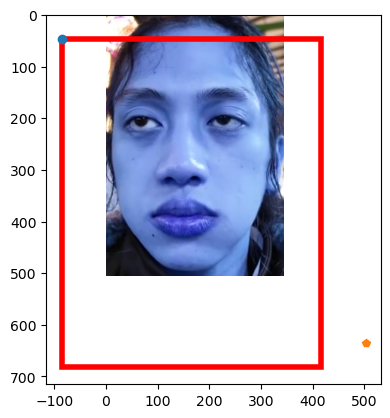

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
ee = cv2.imread('1.png')
ee = cv2.resize(ee,None,fx = 0.75, fy = 0.75)
print(ee.shape)
plt.imshow(ee)
plt.plot(-86,46,'o')
plt.plot(-86+589,46+589,'p')
plt.gca().add_patch(Rectangle((-86,46),-86+589,46+589,
                    edgecolor='red',
                    facecolor='none',
                    lw=4))
plt.show()


In [ ]:
import cv2
import numpy as np
from deepface import DeepFace
import pandas as pd



input_video = cv2.VideoCapture('try.mp4')

dir = "C:/Users/Jai/Desktop/projects/jp/faces"

def mosaic(image, x, y, w, h, blur_level=95):
    if w > 0 and h > 0:
        roi = image[y:y+h, x:x+w]
        if roi.size != 0:
            blurred_roi = cv2.GaussianBlur(roi, (blur_level, blur_level), 0)
            image[y:y+h, x:x+w] = blurred_roi
    return image
count = 0
while True:
    ret, frame = input_video.read()
    if not ret:
        print('no vid')
        break
    
    result = DeepFace.find(img_path=frame,db_path='faces',enforce_detection=False,threshold=0.5)
    if isinstance(result, list) and all(df.empty for df in result):
        print('no matches')
    else:
        if isinstance(result, list) and len(result) > 0 and not result[0].empty:
            first_match = result[0]
            coordinates = first_match[['source_x', 'source_y', 'source_w', 'source_h']].iloc[0]
            cv2.rectangle(frame, (coordinates[0], coordinates[1]), (coordinates[2], coordinates[3]), (0, 0, 255), 2)
            cv2.imwrite("eeee/frame%d.jpg" % count, frame)
    count = count+1
    print('FRAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE::: ',count)
# Release the video objects
input_video.release()
# output_video.release()
cv2.destroyAllWindows()


In [ ]:
import torch
    
print("Torch version:",torch.__version__)

print("Is CUDA enabled?",torch.cuda.is_available())

Torch version: 2.2.2+cu121
Is CUDA enabled? True


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
import os
import face_recognition
faces = []
for name in os.listdir("faces"):
    if name.endswith(".png"):
        image_path = os.path.join("faces", name)
        image = face_recognition.load_image_file(image_path)
        encodings = face_recognition.face_encodings(image)
        
        if encodings:  # Check if encodings list is not empty
            encoding = encodings[0]
            faces.append(encoding)
            print(image_path, encoding)
        else:
            print(f"No faces found in {image_path}")

faces\1.png [-0.11528183  0.0207576   0.067872   -0.05667717 -0.03487608 -0.04487258
 -0.06100275 -0.14558293  0.15245341 -0.11424071  0.24168432 -0.00930091
 -0.12776935 -0.06266793  0.04296505  0.14976738 -0.14673463 -0.08491258
 -0.00794045 -0.00954853  0.07569702 -0.08116142  0.00632023  0.09231341
 -0.20379727 -0.28738493 -0.18474357 -0.07940403  0.03995736 -0.00499232
 -0.09035691  0.00119939 -0.21832848 -0.03251848 -0.00918044  0.11686008
  0.00344563 -0.01989953  0.1433585   0.04098083 -0.20570867  0.04251885
 -0.02575683  0.17663762  0.18551335  0.09511004  0.06814585 -0.06933179
  0.08685013 -0.14922206  0.09281322  0.10619231  0.11981734  0.07873957
 -0.04257108 -0.1699118   0.02411065  0.10192381 -0.18582205  0.05015627
  0.06440834 -0.0906264  -0.00678191 -0.03821723  0.23221701  0.14680484
 -0.15737423 -0.14305317  0.12685721 -0.12619212 -0.02301361  0.03345001
 -0.18949704 -0.20740734 -0.35952243  0.09151793  0.43638629  0.12492622
 -0.1953222   0.02611434 -0.10272101  0

In [ ]:
import cv2
import face_recognition
import os

def mosaic(image, x, y, w, h, blur_level=95):
    if w > 0 and h > 0:
        roi = image[y:y+h, x:x+w]
        if roi.size != 0:
            blurred_roi = cv2.GaussianBlur(roi, (blur_level, blur_level), 0)
            image[y:y+h, x:x+w] = blurred_roi
    return image

faces = []
for name in os.listdir("faces"):
    if name.endswith(".png"):
        image_path = os.path.join("faces", name)
        image = face_recognition.load_image_file(image_path)
        encodings = face_recognition.face_encodings(image)
        
        if encodings:  # Check if encodings list is not empty
            encoding = encodings[0]
            faces.append(encoding)
            print(image_path, encoding)
        else:
            print(f"No faces found in {image_path}")

known_face_names = []
known_face_encodings = []

# Open the input video
input_video = cv2.VideoCapture('try.mp4')
if not input_video.isOpened():
  raise ValueError("Error opening video stream or file.")

# length = int(input_video.get(cv2.CAP_PROP_FRAME_COUNT))
# width = int(input_video.get(cv2.CAP_PROP_FRAME_WIDTH))
# height = int(input_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
# fps = int(input_video.get(cv2.CAP_PROP_FPS))

# # Initialize the video writer for the output video
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# output_video = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

count = 0
while True:
    ret, frame = input_video.read()
    if not ret:
        break
    print(frame.shape)
    cv2.resize(frame, (360,640,3))
    count += 1
    if count % 10 == 0:
        location  = face_recognition.face_locations(frame,model='cnn')
        encodings = face_recognition.face_encodings(frame,location)

        for face_encodings,face_locations in zip(encodings,location):
            results = face_recognition.compare_faces(faces,face_encodings,tolerance=0.7)
            top_left = (face_locations[3],face_locations[0])
            bottom_right = (face_locations[1],face_locations[2])
            cv2.rectangle(frame,top_left,bottom_right,(255,0,0),3)
            cv2.imwrite("cnn/frame%d.jpg" % count, frame)
            print("FRAME: ",count)
        # output_video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        if cv2.waitKey(5) & 0xFF == ord('q'): 
            break
input_video.release()


faces\2.png [-0.07558145  0.03703917  0.07406574 -0.0857746  -0.02429424 -0.01864846
 -0.11795118 -0.10871711  0.15604283 -0.13660991  0.23638454 -0.02359277
 -0.18160321 -0.07904749 -0.01757842  0.17926234 -0.12775987 -0.17070116
  0.00102548 -0.02771795  0.03992588 -0.03013486  0.018009    0.13652036
 -0.15880722 -0.32117319 -0.15967055 -0.14554952 -0.05326391 -0.04517358
 -0.07507309  0.00293102 -0.19683567  0.01154442 -0.00230029  0.06797586
  0.02966255 -0.02495706  0.12899572  0.06738853 -0.20165506  0.03605689
 -0.03193311  0.21221729  0.17318881  0.05593184  0.06622931 -0.06264972
  0.03996456 -0.16143441  0.11962906  0.13075754  0.09840824  0.0474505
 -0.01752712 -0.14074589  0.00173338  0.12184631 -0.15128528  0.08127867
  0.05305262 -0.10211304 -0.03930359 -0.03630769  0.25845274  0.15960456
 -0.15416929 -0.16285789  0.17297541 -0.14251864 -0.0656635   0.02782712
 -0.19484402 -0.17745705 -0.31338215  0.08960918  0.39459351  0.14320135
 -0.22464277  0.06902649 -0.09087683  0.

TAKEE 2:

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


photo dataset embeddings

In [ ]:
import os
import cv2
import numpy as np
from deepface import DeepFace
import faiss

# Function to get embeddings for an image
def get_embedding(image_path, model_name='ArcFace'):
    image = cv2.imread(image_path)
    embedding = DeepFace.represent(image, model_name=model_name, enforce_detection=False)[0]['embedding']
    return np.array(embedding)

# Directory containing the images
image_folder = "/faces"

# List to store embeddings
embeddings = []

# Loop through each image in the folder and get embeddings
for name in os.listdir("faces"):
    if name.endswith(".png"):
        image_path = os.path.join("faces", name)
        embedding = get_embedding(image_path)
        embeddings.append(embedding)

# Convert embeddings list to numpy array
embeddings_array = np.array(embeddings).astype('float32')

# Create a FAISS index
d = embeddings_array.shape[1]  # Dimension of the embeddings
index = faiss.IndexFlatL2(d)  # Using L2 (Euclidean) distance
index.add(embeddings_array)  # Add embeddings to the index

# Save the FAISS index for later use
faiss.write_index(index, "vector_store.index")

print("Vector store created and saved as 'vector_store.index'")


In [ ]:
import cv2
import numpy as np
from deepface import DeepFace
import retinaface
import faiss
import torch
from deepface.modules.verification import find_threshold


# Load the FAISS index and move it to the GPU
all_d=[]
cpu_index = faiss.read_index("vector_store.index")
res = faiss.StandardGpuResources()  # Use a single GPU
gpu_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)

# Function to apply mosaic effect
def mosaic(image, x, y, w, h, blur_level=95):
    if w > 0 and h > 0:
        roi = image[y:y+h, x:x+w]
        if roi.size != 0:
            blurred_roi = cv2.GaussianBlur(roi, (blur_level, blur_level), 0)
            image[y:y+h, x:x+w] = blurred_roi
    return image

# Open the input video
input_video = cv2.VideoCapture('/kaggle/input/video-file/try.mp4')
length = int(input_video.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(input_video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(input_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(input_video.get(cv2.CAP_PROP_FPS))

# Initialize the video writer for the output video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_video = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

# Define the threshold for comparison
threshold = 5.0
count = 0
while True:
    ret, frame = input_video.read()
    if not ret:
        break
    print("Processing Frame: ", count)
    count += 1
    if count % 5 == 0:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        detected_faces = retinaface.RetinaFace.detect_faces(frame_rgb)

        for key in detected_faces.keys():
            identity = detected_faces[key]
            facial_area = identity['facial_area']

            x, y, w, h = facial_area[0], facial_area[1], facial_area[2] - facial_area[0], facial_area[3] - facial_area[1]

            face_region = frame_rgb[y:y+h, x:x+w]

            if face_region.size == 0:
                continue

            face_rep = DeepFace.represent(face_region, model_name='ArcFace', enforce_detection=False)[0]['embedding']
            face_rep = np.array(face_rep).astype('float32').reshape(1, -1)

            # Move face_rep to GPU for search
            face_rep_gpu = torch.tensor(face_rep).to('cuda')
            
            # Search for the nearest neighbor in the FAISS index
            D, I = gpu_index.search(face_rep_gpu.cpu().numpy(), 1, )
            all_d.append(D[0][0])
#             print(D, I, type(D), type(I), D[0][0], threshold, sep='\n\n')
#             break
            # If the distance is greater than the threshold, blur the face
            if D[0][0] > threshold:
                frame = mosaic(frame, x, y, w, h)
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 0, 255), 2)
        output_video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

# # Release the video objects
input_video.release()
output_video.release()
# cv2.destroyAllWindows()


AttributeError: module 'faiss' has no attribute 'StandardGpuResources'

EIGEN FACES

In [ ]:
'''
face detection = mtcnn
face recog = eigen faces?
'''

In [ ]:
!pip install mtcnn

In [ ]:
# from mtcnn import MTCNN
import cv2
from facenet_pytorch import MTCNN


# Create a detector instance
mtcnn = MTCNN(margin=20, keep_all=True, post_process=False, device='cuda:0')

# Load an image
image = cv2.imread("3.jpg")

# Detect faces in the image
boxes, probs, landmarks = mtcnn.detect(image, landmarks=True)
# Display the result
print(boxes[0])

[102.63172912597656 256.52191162109375 154.30926513671875
 327.59173583984375]


In [ ]:
len(boxes)

28

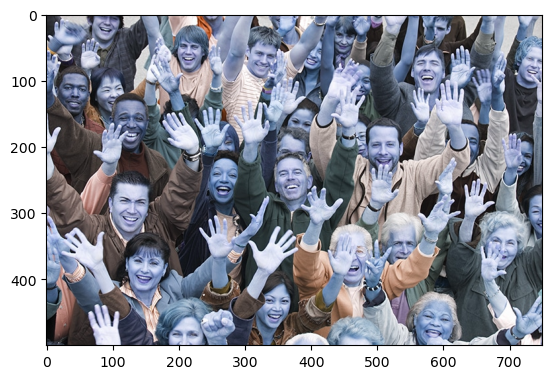

In [ ]:
plt.imshow(image)
plt.show()

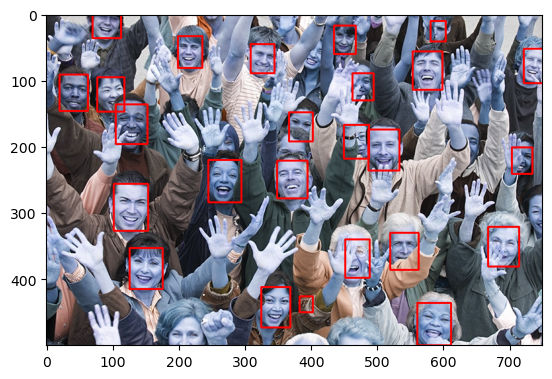

In [ ]:
# Convert coordinates to integers before drawing rectangle
for i in range(len(boxes)):
    x1, y1, x2, y2 = map(int, boxes[i])  #int cuz cv2.rect needs int
    cv2.rectangle(image, (x1, y1), (x2 ,y2), (255, 0, 0), 2)
import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()

In [ ]:
!pip install tensorflow-gpu

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [44 lines of output]
      Traceback (most recent call last):
        File "C:\Users\Jai\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\requirements.py", line 35, in __init__
          parsed = _parse_requirement(requirement_string)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\Jai\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 64, in parse_requirement
          return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\Jai\anaconda3\Lib\site-packages\setuptools\_vendor\packaging\_parser.py", line 82, in _parse_requirement
          url, specifier, marker = _parse_requirement_details(tokenizer)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\Jai\

In [ ]:
import cv2
import face_recognition
import os
from facenet_pytorch import MTCNN

def mosaic(image, x, y, w, h, blur_level=95):
    if w > 0 and h > 0:
        roi = image[y:y+h, x:x+w]
        if roi.size != 0:
            blurred_roi = cv2.GaussianBlur(roi, (blur_level, blur_level), 0)
            image[y:y+h, x:x+w] = blurred_roi
    return image

# faces = []
# for name in os.listdir("faces"):
#     if name.endswith(".png"):
#         image_path = os.path.join("faces", name)
#         image = face_recognition.load_image_file(image_path)
#         encodings = face_recognition.face_encodings(image)
        
#         if encodings:  # Check if encodings list is not empty
#             encoding = encodings[0]
#             faces.append(encoding)
#             print(image_path, encoding)
#         else:
#             print(f"No faces found in {image_path}")

input_video = cv2.VideoCapture('test.mp4')
if not input_video.isOpened():
  raise ValueError("Error opening video stream or file.")
else:
    print('parsing video')

output = cv2.VideoWriter("test output.mp4", cv2.VideoWriter_fourcc(*'mp4v'),  30, (1080, 1920)) 

mtcnn = MTCNN(margin=20, keep_all=True, post_process=False, device='cuda:0')

length = int(input_video.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(input_video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(input_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(input_video.get(cv2.CAP_PROP_FPS))

# # Initialize the video writer for the output video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_video = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

count = 0
while True:
    ret, frame = input_video.read()
    if not ret:
        break
    count += 1
    boxes, probs = mtcnn.detect(frame)
    for i in range(len(boxes)):
        x1, y1, x2, y2 = map(int, boxes[i])  #int cuz cv2.rect needs int
        cv2.rectangle(frame, (x1, y1), (x2 ,y2), (255, 0, 0), 2)


    output_video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    # if cv2.waitKey(5) & 0xFF == ord('q'): 
    #     break
    print(f'{count}/{length}')
input_video.release()
output_video.release()

parsing video
1/392
2/392
3/392
4/392
5/392
6/392
7/392
8/392
9/392
10/392
11/392
12/392
13/392
14/392


: 

In [ ]:
print(count)

392


In [ ]:
import cv2
import torch
from facenet_pytorch import MTCNN
import numpy as np

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def mosaic(image, x, y, w, h, blur_level=95):
    if w > 0 and h > 0:
        roi = image[y:h, x:w]
        if roi.size != 0:
            blurred_roi = cv2.GaussianBlur(roi, (blur_level, blur_level), 0)
            image[y:h, x:w] = blurred_roi
    return image

# Initialize MTCNN with PyTorch
mtcnn = MTCNN(margin=20, keep_all=True, post_process=False, device='cuda:0')

# Open video
input_video = cv2.VideoCapture('test.mp4')
if not input_video.isOpened():
    raise ValueError("Error opening video stream or file.")
else:
    print('Parsing video...')

# Get video properties
length = int(input_video.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(input_video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(input_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(input_video.get(cv2.CAP_PROP_FPS))

print(f"Total frames: {length}")
print(f"Video dimensions: {width}x{height}")
print(f"FPS: {fps}")

# Initialize video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_video = cv2.VideoWriter('test output blur.mp4', fourcc, fps, (width, height))

# Process frames in batches
batch_size = 30  # Adjust based on your GPU memory
count = 0

try:
    while True:
        frames = []
        frames_original = []
        for _ in range(batch_size):
            ret, frame = input_video.read()
            if not ret:
                break
            # Convert BGR to RGB for MTCNN
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            frames_original.append(frame)
        
        if not frames:
            break
            
        # Process batch
        for frame, frame_original in zip(frames, frames_original):
            count += 1
            print(f'Processing frame: {count}/{length} ({(count/length)*100:.1f}%)', end='\r')
            
            try:
                # Detect faces
                # Convert numpy array to PyTorch tensor
                boxes, probs = mtcnn.detect(frame)
                for i in range(len(boxes)):
                    x1, y1, x2, y2 = map(int, boxes[i])  #int cuz cv2.rect needs int
                    cv2.rectangle(frame, (x1, y1), (x2 ,y2), (255, 0, 0), 2)
                if boxes is not None:
                    for box, prob in zip(boxes, probs):
                        if prob > 0.7:  # Confidence threshold
                            # Convert box coordinates to integers
                            box = box.astype(int)
                            x, y, x2, y2 = box
                            w = x2 
                            h = y2 
                            
                            # Draw rectangle
                            cv2.rectangle(frame_original, 
                                        (x, y), 
                                        (w, h), 
                                        (255, 0, 0), 2)
                            
                            # Apply mosaic if needed
                            frame_original = mosaic(frame_original, x, y, w, h)
            except Exception as e:
                pass

            # Write frame
            output_video.write(frame_original)
            # cv2.imshow("processing", frame_original)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                raise KeyboardInterrupt
                
except KeyboardInterrupt:
    print("\nProcessing interrupted by user")
finally:
    print(f"\nProcessed {count} frames")
    # Release resources
    input_video.release()
    output_video.release()
    cv2.destroyAllWindows()
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ModuleNotFoundError: No module named 'cv2'

IT WORKSSSS SHSEEEEEEEEEEEEEESh

In [ ]:
import cv2
import torch
from facenet_pytorch import MTCNN
import numpy as np
import face_recognition
import os

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_known_faces(faces_dir):
    known_face_encodings = []
    known_face_names = []
    
    # Load face images from the faces directory
    for filename in os.listdir(faces_dir):
        if filename.endswith((".png", ".jpg", ".jpeg")):
            image_path = os.path.join(faces_dir, filename)
            face_image = face_recognition.load_image_file(image_path)
            face_encodings = face_recognition.face_encodings(face_image)
            
            if face_encodings:
                known_face_encodings.append(face_encodings[0])
                known_face_names.append(filename)
                print(f"Loaded reference face: {filename}")
            else:
                print(f"No face found in {filename}")
    
    return known_face_encodings, known_face_names

def mosaic(image, x, y, w, h, blur_level=95):
    if w > 0 and h > 0:
        roi = image[y:h, x:w]
        if roi.size != 0:
            blurred_roi = cv2.GaussianBlur(roi, (blur_level, blur_level), 0)
            image[y:h, x:w] = blurred_roi
    return image

# Load known faces
print("Loading reference faces...")
known_face_encodings, known_face_names = load_known_faces("faces")
print(f"Loaded {len(known_face_encodings)} reference faces")

# Initialize MTCNN with PyTorch
mtcnn = MTCNN(margin=20, keep_all=True, post_process=False, device='cuda:0')

# Open video
input_video = cv2.VideoCapture('try.mp4')
if not input_video.isOpened():
    raise ValueError("Error opening video stream or file.")
else:
    print('Parsing video...')

# Get video properties
length = int(input_video.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(input_video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(input_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(input_video.get(cv2.CAP_PROP_FPS))

print(f"Total frames: {length}")
print(f"Video dimensions: {width}x{height}")
print(f"FPS: {fps}")

# Initialize video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_video = cv2.VideoWriter('try output blur.mp4', fourcc, fps, (width, height))

# Process frames in batches
batch_size = 90  # Adjust based on your GPU memory
count = 0

try:
    while True:
        frames = []
        frames_original = []
        for _ in range(batch_size):
            ret, frame = input_video.read()
            if not ret:
                break
            # Convert BGR to RGB for MTCNN
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            frames_original.append(frame)
        
        if not frames:
            break
            
        # Process batch
        for frame, frame_original in zip(frames, frames_original):
            count += 1
            print(f'Processing frame: {count}/{length} ({(count/length)*100:.1f}%)', end='\r')
            
            try:
                # Detect faces using MTCNN
                boxes, probs = mtcnn.detect(frame)
                
                if boxes is not None:
                    for box, prob in zip(boxes, probs):
                        if prob > 0.8:  # Confidence threshold
                            # Convert box coordinates to integers
                            print(prob)
                            box = box.astype(int)
                            x, y, x2, y2 = box
                            
                            # Extract face region for recognition
                            face_region = frame[y:y2, x:x2]
                            if face_region.size == 0:
                                continue
                                
                            # Get face encoding
                            face_encoding = face_recognition.face_encodings(face_region)
                            
                            if face_encoding:
                                # Compare with known faces
                                matches = face_recognition.compare_faces(known_face_encodings, face_encoding[0], tolerance=0.6)
                                
                                # If no match found, blur the face
                                if not any(matches):
                                    frame_original = mosaic(frame_original, x, y, x2, y2)
                                else:
                                    # Draw green rectangle around recognized face
                                    cv2.rectangle(frame_original, (x, y), (x2, y2), (0, 255, 0), 2)
                            else:
                                # If encoding fails, blur the face
                                frame_original = mosaic(frame_original, x, y, x2, y2)
                                
            except Exception as e:
                print(f"\nError processing frame {count}: {str(e)}")
                pass

            # Write frame
            output_video.write(frame_original)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                raise KeyboardInterrupt
                
except KeyboardInterrupt:
    print("\nProcessing interrupted by user")
finally:
    print(f"\nProcessed {count} frames")
    # Release resources
    input_video.release()
    output_video.release()
    cv2.destroyAllWindows()
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Using device: cuda
Loading reference faces...
Loaded reference face: 2.png
Loaded reference face: 3.png
Loaded reference face: 4.png
No face found in 5.png
Loaded reference face: 6.png
Loaded reference face: 7.png
Loaded reference face: 8.png
No face found in 9.png
Loaded 6 reference faces
Parsing video...
Total frames: 4791
Video dimensions: 1280x720
FPS: 59
Processing frame: 1/4791 (0.0%)
Error processing frame 1: compute_face_descriptor(): incompatible function arguments. The following argument types are supported:
    1. (self: _dlib_pybind11.face_recognition_model_v1, img: numpy.ndarray[(rows,cols,3),numpy.uint8], face: _dlib_pybind11.full_object_detection, num_jitters: int = 0, padding: float = 0.25) -> _dlib_pybind11.vector
    2. (self: _dlib_pybind11.face_recognition_model_v1, img: numpy.ndarray[(rows,cols,3),numpy.uint8], num_jitters: int = 0) -> _dlib_pybind11.vector
    3. (self: _dlib_pybind11.face_recognition_model_v1, img: numpy.ndarray[(rows,cols,3),numpy.uint8], faces:

In [ ]:
import os
os.system('python -m venv video')

In [ ]:
import os; os.system('python -m venv video')

0

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the video
video = cv2.VideoCapture('input.mp4')

# Check if video was opened successfully
if not video.isOpened():
    print('Error opening video file')
    exit()

# Get video properties
frame_width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_rate = int(video.get(cv2.CAP_PROP_FPS))

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output.mp4', fourcc, frame_rate, (frame_width, frame_height))

# Process each frame
while True:
    ret, frame = video.read()
    if not ret:
        break

    # Convert BGR to RGB for matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Display the frame
    plt.imshow(frame_rgb)
    plt.title('Video Frame')
    plt.axis('off')
    plt.show()

    # Write the frame to output video
    out.write(frame)

# Release everything when video processing is completed
video.release()
out.release()
print('Video processed successfully')

ModuleNotFoundError: No module named 'matplotlib'

claude masti


In [ ]:
import os
import cv2
import torch
import numpy as np
from facenet_pytorch import MTCNN

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------
# Helpers
# ----------------------------
def mosaic(image, x1, y1, x2, y2, blur_level=95):
    h_img, w_img = image.shape[:2]
    x1 = max(0, min(int(x1), w_img - 1))
    y1 = max(0, min(int(y1), h_img - 1))
    x2 = max(0, min(int(x2), w_img))
    y2 = max(0, min(int(y2), h_img))

    if x2 <= x1 or y2 <= y1:
        return image

    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        return image

    k = int(blur_level)
    if k % 2 == 0:
        k += 1
    k = max(3, k)

    image[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (k, k), 0)
    return image


def load_known_faces_single_identity_lbph(faces_dir, target_size=(100, 100)):
    faces = []
    for filename in sorted(
        os.listdir(faces_dir),
        key=lambda s: int(os.path.splitext(s)[0]) if os.path.splitext(s)[0].isdigit() else s
    ):
        if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        path = os.path.join(faces_dir, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"  [warn] Failed to load {filename}")
            continue
        img = cv2.resize(img, target_size)
        faces.append(img)

    if not faces:
        raise ValueError(f"No training images found in {faces_dir}")

    print(f"  Loaded {len(faces)} allowlist image(s) from '{faces_dir}'")
    labels = np.zeros((len(faces),), dtype=np.int32)   # all same person => label 0
    return faces, labels


def _create_tracker():
    """Return fastest available OpenCV tracker."""
    for factory in [
        lambda: cv2.legacy.TrackerMOSSE_create(),
        lambda: cv2.TrackerMOSSE_create(),
        lambda: cv2.legacy.TrackerKCF_create(),
        lambda: cv2.TrackerKCF_create(),
    ]:
        try:
            return factory()
        except AttributeError:
            continue
    raise RuntimeError("No suitable OpenCV tracker found.")


# ----------------------------
# Load allowlist + train LBPH
# ----------------------------
print("Loading allowlist faces and training LBPH …")
known_faces, known_label_ids = load_known_faces_single_identity_lbph("faces", (100, 100))
lbph_model = cv2.face.LBPHFaceRecognizer_create()
lbph_model.train(known_faces, known_label_ids)
print("LBPH model ready.\n")

# ----------------------------
# Face detector (MTCNN)
# ----------------------------
mtcnn = MTCNN(margin=20, keep_all=True, post_process=False, device=device)

# ----------------------------
# Video I/O
# ----------------------------
input_path  = "try.mp4"
output_path = "try output blur.mp4"

cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise ValueError("Error opening video stream or file.")

length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
fps    = int(round(fps)) if fps and fps > 0 else 30

print(f"Input  : {input_path}")
print(f"Output : {output_path}")
print(f"Frames : {length}  |  Size: {width}x{height}  |  FPS: {fps}\n")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# ----------------------------
# Processing settings
# ----------------------------
LBPH_ACCEPT_MAX  = 60    # lower  → stricter (harder to be recognised as allowlisted)
BLUR_LEVEL       = 95    # gaussian kernel size (odd; auto-fixed if even)
MTCNN_PROB_MIN   = 0.80  # minimum detector confidence to consider a detection
DETECT_EVERY     = 5     # run MTCNN+LBPH every N frames; track in between
DETECT_SCALE     = 0.5   # downscale factor for MTCNN (speed vs accuracy)
MIN_FACE_SIZE    = 40    # faces smaller than this (px) are blurred without LBPH
PRINT_EVERY      = 100   # console progress interval

# ----------------------------
# Main loop
# ----------------------------
# tracks: list of {"tracker": cv2.Tracker, "allow": bool}
tracks    = []
frame_idx = 0
count     = 0

try:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_idx += 1
        count     += 1

        if count % PRINT_EVERY == 0 or count == 1:
            pct = f" ({count/length*100:.1f}%)" if length > 0 else ""
            print(f"  Frame {count}/{length}{pct}")

        do_detect = (frame_idx % DETECT_EVERY == 1) or (len(tracks) == 0)

        if do_detect:
            tracks = []

            # ── Detect faces on a (optionally downscaled) RGB frame ──
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            if DETECT_SCALE != 1.0:
                small_rgb = cv2.resize(
                    frame_rgb, None,
                    fx=DETECT_SCALE, fy=DETECT_SCALE,
                    interpolation=cv2.INTER_LINEAR
                )
            else:
                small_rgb = frame_rgb

            boxes, probs = mtcnn.detect(small_rgb)

            if boxes is not None and probs is not None:
                inv = 1.0 / DETECT_SCALE
                h_img, w_img = frame_bgr.shape[:2]

                for box, prob in zip(boxes, probs):
                    if prob is None or prob < MTCNN_PROB_MIN:
                        continue

                    # Scale boxes back to full resolution
                    x1 = max(0, min(int(round(box[0] * inv)), w_img - 1))
                    y1 = max(0, min(int(round(box[1] * inv)), h_img - 1))
                    x2 = max(0, min(int(round(box[2] * inv)), w_img))
                    y2 = max(0, min(int(round(box[3] * inv)), h_img))

                    if x2 <= x1 or y2 <= y1:
                        continue

                    # ── Tiny face: blur immediately, skip LBPH ──
                    if (x2 - x1) < MIN_FACE_SIZE or (y2 - y1) < MIN_FACE_SIZE:
                        frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                        continue

                    # ── LBPH recognition ──
                    face_bgr = frame_bgr[y1:y2, x1:x2]
                    if face_bgr.size == 0:
                        continue

                    gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
                    gray = cv2.resize(gray, (100, 100))

                    _, confidence = lbph_model.predict(gray)
                    allow = (confidence <= LBPH_ACCEPT_MAX)

                    # ── FIX: blur non-allowed faces on the detection frame too ──
                    if not allow:
                        frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)

                    # Initialise tracker for subsequent frames
                    tr = _create_tracker()
                    tr.init(frame_bgr, (x1, y1, x2 - x1, y2 - y1))
                    tracks.append({"tracker": tr, "allow": allow})

        else:
            # ── Tracking frames: update trackers, blur as needed ──
            new_tracks = []
            for t in tracks:
                ok, bbox = t["tracker"].update(frame_bgr)
                if not ok:
                    continue   # tracker lost the face; drop it

                x, y, w, h = bbox
                x1, y1 = int(x), int(y)
                x2, y2 = int(x + w), int(y + h)

                if not t["allow"]:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)

                new_tracks.append(t)
            tracks = new_tracks

        out.write(frame_bgr)

except KeyboardInterrupt:
    print("\nInterrupted by user.")
finally:
    print(f"\nProcessed {count} frame(s).")
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Done. Output saved to: {output_path}")

RuntimeError: operator torchvision::nms does not exist

mediapipe


In [3]:
import os
import urllib.request
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# ----------------------------
# Download model if needed
# ----------------------------
MODEL_PATH = "blaze_face_short_range.tflite"
MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_detector/blaze_face_short_range/float16/1/"
    "blaze_face_short_range.tflite"
)
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face model ...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"  Saved to {MODEL_PATH}\n")

# ----------------------------
# Helpers
# ----------------------------
def mosaic(image, x1, y1, x2, y2, blur_level=95):
    h_img, w_img = image.shape[:2]
    x1 = max(0, min(int(x1), w_img - 1))
    y1 = max(0, min(int(y1), h_img - 1))
    x2 = max(0, min(int(x2), w_img))
    y2 = max(0, min(int(y2), h_img))
    if x2 <= x1 or y2 <= y1:
        return image
    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        return image
    k = int(blur_level)
    if k % 2 == 0:
        k += 1
    k = max(3, k)
    image[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (k, k), 0)
    return image


def load_known_faces_lbph(faces_dir, target_size=(100, 100)):
    faces = []
    for filename in sorted(
        os.listdir(faces_dir),
        key=lambda s: int(os.path.splitext(s)[0])
        if os.path.splitext(s)[0].isdigit() else s,
    ):
        if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        path = os.path.join(faces_dir, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"  [warn] Failed to load {filename}")
            continue
        img = cv2.resize(img, target_size)
        faces.append(img)
    if not faces:
        raise ValueError(f"No training images found in '{faces_dir}'")
    print(f"  Loaded {len(faces)} allowlist image(s) from '{faces_dir}'")
    labels = np.zeros((len(faces),), dtype=np.int32)
    return faces, labels


def _create_tracker():
    for factory in [
        lambda: cv2.legacy.TrackerMOSSE_create(),
        lambda: cv2.TrackerMOSSE_create(),
        lambda: cv2.legacy.TrackerKCF_create(),
        lambda: cv2.TrackerKCF_create(),
    ]:
        try:
            return factory()
        except AttributeError:
            continue
    raise RuntimeError("No suitable OpenCV tracker found.")


def detect_faces(detector, frame_rgb, min_score=0.80):
    """Run MediaPipe Tasks detector; return list of (x1,y1,x2,y2) pixel boxes."""
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result   = detector.detect(mp_image)
    boxes    = []
    h, w     = frame_rgb.shape[:2]
    for det in result.detections:
        score = det.categories[0].score if det.categories else 0.0
        if score < min_score:
            continue
        bb = det.bounding_box
        x1 = max(0, min(bb.origin_x,             w - 1))
        y1 = max(0, min(bb.origin_y,             h - 1))
        x2 = max(0, min(bb.origin_x + bb.width,  w))
        y2 = max(0, min(bb.origin_y + bb.height, h))
        if x2 > x1 and y2 > y1:
            boxes.append((x1, y1, x2, y2))
    return boxes


# ----------------------------
# Load allowlist + train LBPH
# ----------------------------
print("Loading allowlist faces and training LBPH ...")
known_faces, known_labels = load_known_faces_lbph("Faces", (100, 100))
lbph_model = cv2.face.LBPHFaceRecognizer_create()
lbph_model.train(known_faces, known_labels)
print("LBPH model ready.\n")

# ----------------------------
# Face detector (MediaPipe Tasks 0.10+)
# ----------------------------
base_opts = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
det_opts  = mp_vision.FaceDetectorOptions(
    base_options=base_opts,
    min_detection_confidence=0.80,
)
detector = mp_vision.FaceDetector.create_from_options(det_opts)

# ----------------------------
# Video I/O
# ----------------------------
input_path  = "try.mp4"
output_path = "try output blur.mp4"

cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise ValueError("Error opening video file.")

length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
fps    = int(round(fps)) if fps and fps > 0 else 30

print(f"Input  : {input_path}")
print(f"Output : {output_path}")
print(f"Frames : {length}  |  Size: {width}x{height}  |  FPS: {fps}\n")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# ----------------------------
# Processing settings
# ----------------------------
LBPH_ACCEPT_MAX = 60    # lower → stricter recognition
BLUR_LEVEL      = 95    # gaussian kernel size
DETECT_EVERY    = 5     # run detector every N frames; track in between
DETECT_SCALE    = 0.5   # downscale for faster detection
MIN_FACE_SIZE   = 40    # faces smaller than this are blurred without LBPH
PRINT_EVERY     = 100   # console progress interval

tracks    = []
frame_idx = 0
count     = 0

try:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_idx += 1
        count     += 1

        if count % PRINT_EVERY == 0 or count == 1:
            pct = f" ({count/length*100:.1f}%)" if length > 0 else ""
            print(f"  Frame {count}/{length}{pct}")

        do_detect = (frame_idx % DETECT_EVERY == 1) or (len(tracks) == 0)

        if do_detect:
            tracks = []

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            if DETECT_SCALE != 1.0:
                small_rgb = cv2.resize(
                    frame_rgb, None,
                    fx=DETECT_SCALE, fy=DETECT_SCALE,
                    interpolation=cv2.INTER_LINEAR,
                )
            else:
                small_rgb = frame_rgb

            inv            = 1.0 / DETECT_SCALE
            h_img, w_img   = frame_bgr.shape[:2]

            for (sx1, sy1, sx2, sy2) in detect_faces(detector, small_rgb):
                # Scale back to full resolution
                x1 = max(0, min(int(round(sx1 * inv)), w_img - 1))
                y1 = max(0, min(int(round(sy1 * inv)), h_img - 1))
                x2 = max(0, min(int(round(sx2 * inv)), w_img))
                y2 = max(0, min(int(round(sy2 * inv)), h_img))
                if x2 <= x1 or y2 <= y1:
                    continue

                # Tiny face → blur without LBPH
                if (x2 - x1) < MIN_FACE_SIZE or (y2 - y1) < MIN_FACE_SIZE:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                    continue

                # LBPH recognition
                face_bgr = frame_bgr[y1:y2, x1:x2]
                if face_bgr.size == 0:
                    continue
                gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
                gray = cv2.resize(gray, (100, 100))
                _, confidence = lbph_model.predict(gray)
                allow = confidence <= LBPH_ACCEPT_MAX

                # Blur non-allowed faces on this detection frame
                if not allow:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)

                # Init tracker for subsequent frames
                tr = _create_tracker()
                tr.init(frame_bgr, (x1, y1, x2 - x1, y2 - y1))
                tracks.append({"tracker": tr, "allow": allow})

        else:
            # Tracking frames — no detection, just update trackers
            new_tracks = []
            for t in tracks:
                ok, bbox = t["tracker"].update(frame_bgr)
                if not ok:
                    continue
                x, y, w, h = bbox
                x1, y1 = int(x),     int(y)
                x2, y2 = int(x + w), int(y + h)
                if not t["allow"]:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                new_tracks.append(t)
            tracks = new_tracks

        out.write(frame_bgr)

except KeyboardInterrupt:
    print("\nInterrupted by user.")
finally:
    print(f"\nProcessed {count} frame(s).")
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    detector.close()

print(f"Done. Output saved to: {output_path}")

Loading allowlist faces and training LBPH ...
  Loaded 8 allowlist image(s) from 'Faces'
LBPH model ready.

Input  : try.mp4
Output : try output blur.mp4
Frames : 4791  |  Size: 1920x1080  |  FPS: 60

  Frame 1/4791 (0.0%)


I0000 00:00:1778955957.579096    9960 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778955957.582462    9980 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.2-arch1.1), renderer: Mesa Intel(R) Graphics (RPL-P)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778955957.585244    9965 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  Frame 100/4791 (2.1%)
  Frame 200/4791 (4.2%)
  Frame 300/4791 (6.3%)
  Frame 400/4791 (8.3%)
  Frame 500/4791 (10.4%)
  Frame 600/4791 (12.5%)
  Frame 700/4791 (14.6%)
  Frame 800/4791 (16.7%)
  Frame 900/4791 (18.8%)
  Frame 1000/4791 (20.9%)
  Frame 1100/4791 (23.0%)
  Frame 1200/4791 (25.0%)
  Frame 1300/4791 (27.1%)
  Frame 1400/4791 (29.2%)
  Frame 1500/4791 (31.3%)
  Frame 1600/4791 (33.4%)
  Frame 1700/4791 (35.5%)
  Frame 1800/4791 (37.6%)
  Frame 1900/4791 (39.7%)
  Frame 2000/4791 (41.7%)
  Frame 2100/4791 (43.8%)
  Frame 2200/4791 (45.9%)
  Frame 2300/4791 (48.0%)
  Frame 2400/4791 (50.1%)
  Frame 2500/4791 (52.2%)
  Frame 2600/4791 (54.3%)
  Frame 2700/4791 (56.4%)
  Frame 2800/4791 (58.4%)
  Frame 2900/4791 (60.5%)
  Frame 3000/4791 (62.6%)
  Frame 3100/4791 (64.7%)
  Frame 3200/4791 (66.8%)
  Frame 3300/4791 (68.9%)
  Frame 3400/4791 (71.0%)
  Frame 3500/4791 (73.1%)
  Frame 3600/4791 (75.1%)
  Frame 3700/4791 (77.2%)
  Frame 3800/4791 (79.3%)
  Frame 3900/4791 (81.4%)

In [ ]:
import os
import urllib.request
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# ----------------------------
# Download model if needed
# ----------------------------
MODEL_PATH = "blaze_face_short_range.tflite"
MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_detector/blaze_face_short_range/float16/1/"
    "blaze_face_short_range.tflite"
)
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face model ...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"  Saved to {MODEL_PATH}\n")

# ----------------------------
# Helpers
# ----------------------------
def mosaic(image, x1, y1, x2, y2, blur_level=95):
    h_img, w_img = image.shape[:2]
    x1 = max(0, min(int(x1), w_img - 1))
    y1 = max(0, min(int(y1), h_img - 1))
    x2 = max(0, min(int(x2), w_img))
    y2 = max(0, min(int(y2), h_img))
    if x2 <= x1 or y2 <= y1:
        return image
    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        return image
    k = int(blur_level)
    if k % 2 == 0:
        k += 1
    k = max(3, k)
    image[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (k, k), 0)
    return image


def iou(a, b):
    """Intersection-over-Union of two (x1,y1,x2,y2) boxes."""
    ix1 = max(a[0], b[0])
    iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2])
    iy2 = min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)


def load_known_faces_lbph(faces_dir, target_size=(100, 100)):
    faces = []
    for filename in sorted(
        os.listdir(faces_dir),
        key=lambda s: (0, int(os.path.splitext(s)[0])) if os.path.splitext(s)[0].isdigit() else (1, s),
    ):
        if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        path = os.path.join(faces_dir, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"  [warn] Failed to load {filename}")
            continue
        img = cv2.resize(img, target_size)
        faces.append(img)
    if not faces:
        raise ValueError(f"No training images found in '{faces_dir}'")
    print(f"  Loaded {len(faces)} allowlist image(s) from '{faces_dir}'")
    labels = np.zeros((len(faces),), dtype=np.int32)
    return faces, labels


def _create_tracker():
    for factory in [
        lambda: cv2.legacy.TrackerMOSSE_create(),
        lambda: cv2.TrackerMOSSE_create(),
        lambda: cv2.legacy.TrackerKCF_create(),
        lambda: cv2.TrackerKCF_create(),
    ]:
        try:
            return factory()
        except AttributeError:
            continue
    raise RuntimeError("No suitable OpenCV tracker found.")


def detect_faces(detector, frame_rgb, min_score=0.80):
    """Return list of (x1,y1,x2,y2) pixel boxes from MediaPipe Tasks."""
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    result   = detector.detect(mp_image)
    boxes    = []
    h, w     = frame_rgb.shape[:2]
    for det in result.detections:
        score = det.categories[0].score if det.categories else 0.0
        if score < min_score:
            continue
        bb = det.bounding_box
        x1 = max(0, min(bb.origin_x,             w - 1))
        y1 = max(0, min(bb.origin_y,             h - 1))
        x2 = max(0, min(bb.origin_x + bb.width,  w))
        y2 = max(0, min(bb.origin_y + bb.height, h))
        if x2 > x1 and y2 > y1:
            boxes.append((x1, y1, x2, y2))
    return boxes


# ----------------------------
# Load allowlist + train LBPH
# ----------------------------
print("Loading allowlist faces and training LBPH ...")
known_faces, known_labels = load_known_faces_lbph("Faces", (100, 100))
lbph_model = cv2.face.LBPHFaceRecognizer_create()
lbph_model.train(known_faces, known_labels)
print("LBPH model ready.\n")

# ----------------------------
# Face detector (MediaPipe Tasks 0.10+)
# ----------------------------
base_opts = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
det_opts  = mp_vision.FaceDetectorOptions(
    base_options=base_opts,
    min_detection_confidence=0.80,
)
detector = mp_vision.FaceDetector.create_from_options(det_opts)

# ----------------------------
# Video I/O
# ----------------------------
input_path  = "try.mp4"
output_path = "try output blur.mp4"

cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise ValueError("Error opening video file.")

length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
fps    = int(round(fps)) if fps and fps > 0 else 30

print(f"Input  : {input_path}")
print(f"Output : {output_path}")
print(f"Frames : {length}  |  Size: {width}x{height}  |  FPS: {fps}\n")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# ----------------------------
# Processing settings
# ----------------------------
LBPH_ACCEPT_MAX  = 100   # lower → stricter recognition
BLUR_LEVEL       = 95   # gaussian kernel size
DETECT_EVERY     = 5    # run detector every N frames; track in between
DETECT_SCALE     = 0.75  # downscale for faster detection
MIN_FACE_SIZE    = 20  # faces smaller than this are blurred without LBPH
PRINT_EVERY      = 100  # console progress interval

# Anti-flicker settings
IOU_MATCH_THRESH = 0.30  # min IoU to link a new detection to an existing track
ALLOW_VOTES_NEED = 4     # consecutive "allow" detections needed to stop blurring
#   → face starts as blurred; only cleared after ALLOW_VOTES_NEED detections in a row

# ----------------------------
# Track structure:
#   tracker   : cv2 tracker
#   allow     : bool  (current effective decision shown on screen)
#   allow_streak : int  (consecutive allow detections; resets to 0 on any blur hit)
#   box       : (x1,y1,x2,y2)  last known full-res box (for IoU matching)
# ----------------------------
tracks    = []
frame_idx = 0
count     = 0

try:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_idx += 1
        count     += 1

        if count % PRINT_EVERY == 0 or count == 1:
            pct = f" ({count/length*100:.1f}%)" if length > 0 else ""
            print(f"  Frame {count}/{length}{pct}")

        do_detect = (frame_idx % DETECT_EVERY == 1) or (len(tracks) == 0)

        if do_detect:
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            if DETECT_SCALE != 1.0:
                small_rgb = cv2.resize(
                    frame_rgb, None,
                    fx=DETECT_SCALE, fy=DETECT_SCALE,
                    interpolation=cv2.INTER_LINEAR,
                )
            else:
                small_rgb = frame_rgb

            inv          = 1.0 / DETECT_SCALE
            h_img, w_img = frame_bgr.shape[:2]
            raw_boxes    = detect_faces(detector, small_rgb)

            # Scale detections back to full resolution
            full_boxes = []
            for (sx1, sy1, sx2, sy2) in raw_boxes:
                x1 = max(0, min(int(round(sx1 * inv)), w_img - 1))
                y1 = max(0, min(int(round(sy1 * inv)), h_img - 1))
                x2 = max(0, min(int(round(sx2 * inv)), w_img))
                y2 = max(0, min(int(round(sy2 * inv)), h_img))
                if x2 > x1 and y2 > y1:
                    full_boxes.append((x1, y1, x2, y2))

            new_tracks    = []
            used_old      = set()   # indices of old tracks already matched

            for (x1, y1, x2, y2) in full_boxes:

                # ── Tiny face: blur immediately, no tracking ──
                if (x2 - x1) < MIN_FACE_SIZE or (y2 - y1) < MIN_FACE_SIZE:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                    continue

                # ── LBPH recognition ──
                face_bgr = frame_bgr[y1:y2, x1:x2]
                if face_bgr.size == 0:
                    continue
                gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
                gray = cv2.resize(gray, (100, 100))
                _, confidence  = lbph_model.predict(gray)
                lbph_allow     = confidence <= LBPH_ACCEPT_MAX

                # ── Match to existing track via IoU ──
                best_iou   = IOU_MATCH_THRESH
                best_idx   = -1
                for i, t in enumerate(tracks):
                    if i in used_old:
                        continue
                    score = iou((x1, y1, x2, y2), t["box"])
                    if score > best_iou:
                        best_iou = score
                        best_idx = i

                if best_idx >= 0:
                    # Carry over streak from matched track
                    old = tracks[best_idx]
                    used_old.add(best_idx)
                    streak = old["allow_streak"]
                else:
                    streak = 0   # brand-new face → start from zero

                # Update streak
                if lbph_allow:
                    streak += 1
                else:
                    streak = 0   # any blur hit resets the streak

                # Only allow (unblur) if streak has reached threshold
                effective_allow = (streak >= ALLOW_VOTES_NEED)

                if not effective_allow:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)

                tr = _create_tracker()
                tr.init(frame_bgr, (x1, y1, x2 - x1, y2 - y1))
                new_tracks.append({
                    "tracker":      tr,
                    "allow":        effective_allow,
                    "allow_streak": streak,
                    "box":          (x1, y1, x2, y2),
                })

            tracks = new_tracks

        else:
            # ── Tracking frames ──
            new_tracks = []
            for t in tracks:
                ok, bbox = t["tracker"].update(frame_bgr)
                if not ok:
                    continue
                x, y, w, h = bbox
                x1, y1 = int(x),     int(y)
                x2, y2 = int(x + w), int(y + h)
                # Update stored box for next IoU match
                t["box"] = (x1, y1, x2, y2)
                if not t["allow"]:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                new_tracks.append(t)
            tracks = new_tracks

        out.write(frame_bgr)

except KeyboardInterrupt:
    print("\nInterrupted by user.")
finally:
    print(f"\nProcessed {count} frame(s).")
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    detector.close()

print(f"Done. Output saved to: {output_path}")

Loading allowlist faces and training LBPH ...
  Loaded 33 allowlist image(s) from 'Faces'
LBPH model ready.

Input  : try.mp4
Output : try output blur.mp4
Frames : 4791  |  Size: 1920x1080  |  FPS: 60

  Frame 1/4791 (0.0%)


I0000 00:00:1778957353.215561   18561 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778957353.216985   18579 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.2-arch1.1), renderer: Mesa Intel(R) Graphics (RPL-P)
W0000 00:00:1778957353.218785   18565 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  Frame 100/4791 (2.1%)
  Frame 200/4791 (4.2%)
  Frame 300/4791 (6.3%)
  Frame 400/4791 (8.3%)
  Frame 500/4791 (10.4%)
  Frame 600/4791 (12.5%)
  Frame 700/4791 (14.6%)
  Frame 800/4791 (16.7%)
  Frame 900/4791 (18.8%)
  Frame 1000/4791 (20.9%)
  Frame 1100/4791 (23.0%)
  Frame 1200/4791 (25.0%)
  Frame 1300/4791 (27.1%)
  Frame 1400/4791 (29.2%)
  Frame 1500/4791 (31.3%)
  Frame 1600/4791 (33.4%)
  Frame 1700/4791 (35.5%)
  Frame 1800/4791 (37.6%)
  Frame 1900/4791 (39.7%)
  Frame 2000/4791 (41.7%)
  Frame 2100/4791 (43.8%)
  Frame 2200/4791 (45.9%)
  Frame 2300/4791 (48.0%)
  Frame 2400/4791 (50.1%)
  Frame 2500/4791 (52.2%)
  Frame 2600/4791 (54.3%)
  Frame 2700/4791 (56.4%)
  Frame 2800/4791 (58.4%)
  Frame 2900/4791 (60.5%)
  Frame 3000/4791 (62.6%)
  Frame 3100/4791 (64.7%)
  Frame 3200/4791 (66.8%)
  Frame 3300/4791 (68.9%)
  Frame 3400/4791 (71.0%)
  Frame 3500/4791 (73.1%)
  Frame 3600/4791 (75.1%)
  Frame 3700/4791 (77.2%)
  Frame 3800/4791 (79.3%)
  Frame 3900/4791 (81.4%)

yolo


In [9]:
import os
import urllib.request
import cv2
import numpy as np
from ultralytics import YOLO
import insightface
from insightface.app import FaceAnalysis

# ----------------------------
# Download YOLOv8 face model if needed
# ----------------------------
MODEL_PATH = "yolov8n-face.pt"
MODEL_URL  = "https://huggingface.co/arnabdhar/YOLOv8-Face-Detection/resolve/main/model.pt"

if not os.path.exists(MODEL_PATH):
    print("Downloading YOLOv8 face model ...")
    import requests
    r = requests.get(MODEL_URL, stream=True)
    r.raise_for_status()
    with open(MODEL_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"  Saved to {MODEL_PATH}\n")

# ----------------------------
# Helpers
# ----------------------------
def mosaic(image, x1, y1, x2, y2, blur_level=95):
    h_img, w_img = image.shape[:2]
    x1 = max(0, min(int(x1), w_img - 1))
    y1 = max(0, min(int(y1), h_img - 1))
    x2 = max(0, min(int(x2), w_img))
    y2 = max(0, min(int(y2), h_img))
    if x2 <= x1 or y2 <= y1:
        return image
    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        return image
    k = int(blur_level)
    if k % 2 == 0:
        k += 1
    k = max(3, k)
    image[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (k, k), 0)
    return image


def iou(a, b):
    ix1 = max(a[0], b[0]);  iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]);  iy2 = min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)


def cosine_similarity(a, b):
    a = a / (np.linalg.norm(a) + 1e-6)
    b = b / (np.linalg.norm(b) + 1e-6)
    return float(np.dot(a, b))


def _create_tracker():
    for factory in [
        lambda: cv2.legacy.TrackerMOSSE_create(),
        lambda: cv2.TrackerMOSSE_create(),
        lambda: cv2.legacy.TrackerKCF_create(),
        lambda: cv2.TrackerKCF_create(),
    ]:
        try:
            return factory()
        except AttributeError:
            continue
    raise RuntimeError("No suitable OpenCV tracker found.")


def detect_faces_yolo(model, frame_bgr, min_conf=0.50):
    """YOLOv8 face detection. Returns list of (x1,y1,x2,y2)."""
    results = model.predict(frame_bgr, conf=min_conf, verbose=False)
    boxes = []
    h, w = frame_bgr.shape[:2]
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            x1 = max(0, min(int(x1), w - 1))
            y1 = max(0, min(int(y1), h - 1))
            x2 = max(0, min(int(x2), w))
            y2 = max(0, min(int(y2), h))
            if x2 > x1 and y2 > y1:
                boxes.append((x1, y1, x2, y2))
    return boxes


def get_embedding(rec_model, face_bgr):
    """
    Get ArcFace embedding for a face crop (BGR).
    Returns 512-d numpy array or None if detection fails.
    """
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    faces = rec_model.get(face_rgb)
    if not faces:
        return None
    # pick the largest face in the crop (should only be one)
    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]))
    return face.normed_embedding


# ----------------------------
# Build allowlist embeddings
# ----------------------------
print("Loading InsightFace ArcFace model ...")
# ctx_id=-1 → CPU; set to 0 for GPU
rec_app = FaceAnalysis(name="buffalo_sc", providers=["CPUExecutionProvider"])
rec_app.prepare(ctx_id=-1, det_size=(320, 320))
print("InsightFace ready.\n")

FACES_DIR = "Faces"
print(f"Building allowlist embeddings from '{FACES_DIR}' ...")
allowlist_embeddings = []

for filename in sorted(os.listdir(FACES_DIR)):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    path = os.path.join(FACES_DIR, filename)
    img  = cv2.imread(path)
    if img is None:
        print(f"  [warn] Could not read {filename}")
        continue
    emb = get_embedding(rec_app, img)
    if emb is None:
        print(f"  [warn] No face detected in {filename} — skipping")
        continue
    allowlist_embeddings.append(emb)
    print(f"  + {filename}")

if not allowlist_embeddings:
    raise ValueError(f"No usable face images found in '{FACES_DIR}'")

print(f"\n  {len(allowlist_embeddings)} allowlist embedding(s) ready.\n")


def is_allowed(face_bgr, threshold=0.40):
    """
    Returns True if face_bgr matches any allowlist embedding.
    threshold: cosine similarity cutoff (0–1). Higher = stricter.
    Tune upward (e.g. 0.45) if wrong people pass through,
    downward (e.g. 0.35) if your person keeps getting blurred.
    """
    emb = get_embedding(rec_app, face_bgr)
    if emb is None:
        return False   # can't detect face in crop → blur it
    best = max(cosine_similarity(emb, ref) for ref in allowlist_embeddings)
    return best >= threshold


# ----------------------------
# YOLOv8 face detector
# ----------------------------
print("Loading YOLOv8 ...")
yolo = YOLO(MODEL_PATH)
print("YOLOv8 ready.\n")

# ----------------------------
# Video I/O
# ----------------------------
input_path  = "try.mp4"
output_path = "1try output blur.mp4"

cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise ValueError("Error opening video file.")

length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
fps    = int(round(fps)) if fps and fps > 0 else 30

print(f"Input  : {input_path}")
print(f"Output : {output_path}")
print(f"Frames : {length}  |  Size: {width}x{height}  |  FPS: {fps}\n")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# ----------------------------
# Processing settings
# ----------------------------
SIMILARITY_THRESHOLD = 0.60  # cosine sim to count as allowed person
                              # lower (0.35) = easier to match (less blur on your person)
                              # higher (0.45) = harder to match (more blur on strangers)
BLUR_LEVEL       = 95
DETECT_EVERY     = 5
DETECT_SCALE     = 0.75
YOLO_CONF        = 0.50
MIN_FACE_SIZE    = 20
PRINT_EVERY      = 100

IOU_MATCH_THRESH = 0.30
ALLOW_VOTES_NEED = 10    # consecutive allow hits needed to unblur

tracks    = []
frame_idx = 0
count     = 0

try:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_idx += 1
        count     += 1

        if count % PRINT_EVERY == 0 or count == 1:
            pct = f" ({count/length*100:.1f}%)" if length > 0 else ""
            print(f"  Frame {count}/{length}{pct}")

        do_detect = (frame_idx % DETECT_EVERY == 1) or (len(tracks) == 0)

        if do_detect:
            if DETECT_SCALE != 1.0:
                small_bgr = cv2.resize(
                    frame_bgr, None,
                    fx=DETECT_SCALE, fy=DETECT_SCALE,
                    interpolation=cv2.INTER_LINEAR,
                )
            else:
                small_bgr = frame_bgr

            inv          = 1.0 / DETECT_SCALE
            h_img, w_img = frame_bgr.shape[:2]
            raw_boxes    = detect_faces_yolo(yolo, small_bgr, min_conf=YOLO_CONF)

            full_boxes = []
            for (sx1, sy1, sx2, sy2) in raw_boxes:
                x1 = max(0, min(int(round(sx1 * inv)), w_img - 1))
                y1 = max(0, min(int(round(sy1 * inv)), h_img - 1))
                x2 = max(0, min(int(round(sx2 * inv)), w_img))
                y2 = max(0, min(int(round(sy2 * inv)), h_img))
                if x2 > x1 and y2 > y1:
                    full_boxes.append((x1, y1, x2, y2))

            new_tracks = []
            used_old   = set()

            for (x1, y1, x2, y2) in full_boxes:

                # Tiny face → blur, no recognition
                if (x2 - x1) < MIN_FACE_SIZE or (y2 - y1) < MIN_FACE_SIZE:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                    continue

                face_bgr   = frame_bgr[y1:y2, x1:x2]
                if face_bgr.size == 0:
                    continue

                # ArcFace recognition
                arc_allow = is_allowed(face_bgr, threshold=SIMILARITY_THRESHOLD)

                # IoU match to carry over streak
                best_iou = IOU_MATCH_THRESH
                best_idx = -1
                for i, t in enumerate(tracks):
                    if i in used_old:
                        continue
                    s = iou((x1, y1, x2, y2), t["box"])
                    if s > best_iou:
                        best_iou = s
                        best_idx = i

                streak = tracks[best_idx]["allow_streak"] if best_idx >= 0 else 0
                if best_idx >= 0:
                    used_old.add(best_idx)

                streak = streak + 1 if arc_allow else 0
                effective_allow = streak >= ALLOW_VOTES_NEED

                if not effective_allow:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)

                tr = _create_tracker()
                tr.init(frame_bgr, (x1, y1, x2 - x1, y2 - y1))
                new_tracks.append({
                    "tracker":      tr,
                    "allow":        effective_allow,
                    "allow_streak": streak,
                    "box":          (x1, y1, x2, y2),
                })

            tracks = new_tracks

        else:
            new_tracks = []
            for t in tracks:
                ok, bbox = t["tracker"].update(frame_bgr)
                if not ok:
                    continue
                x, y, w, h = bbox
                x1, y1 = int(x),     int(y)
                x2, y2 = int(x + w), int(y + h)
                t["box"] = (x1, y1, x2, y2)
                if not t["allow"]:
                    frame_bgr = mosaic(frame_bgr, x1, y1, x2, y2, BLUR_LEVEL)
                new_tracks.append(t)
            tracks = new_tracks

        out.write(frame_bgr)

except KeyboardInterrupt:
    print("\nInterrupted by user.")
finally:
    print(f"\nProcessed {count} frame(s).")
    cap.release()
    out.release()
    cv2.destroyAllWindows()

print(f"Done. Output saved to: {output_path}")

Loading InsightFace ArcFace model ...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jaip/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/jaip/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
InsightFace ready.

Building allowlist embeddings from 'Faces' ...
  + 2.png
  + 3.png
  + 4.png
  + 5.png
  + 6.png
  + 7.png
  + 8.png
  + 9.png
  + img69.jpg
  + img70.jpg
  + img71.jpg
  + img72.jpg
  + img73.jpg
  + img74.jpg
  + img75.jpg
  + img76.jpg
  + img77.jpg
  + img78.jpg
  + img79.jpg
  + img80.jpg
  + img81.jpg
  + img82.jpg
  + img83.jpg
  + img84.jpg
  + img85.jpg
  + img86.jpg
  + img87.jpg
  + img88.jpg
  + img89.jpg
  + img90.jpg
  + img91.jpg
  + img92.jpg
  + img93.jpg

  33 allowlist embedding(s) ready.

Loadi

In [ ]:
import cv2
import face_recognition
import numpy as np
from pathlib import Path

# Load known faces from /Faces folder
directory = Path("/Faces")
known_face_encodings = []
known_face_names = []

for file in directory.glob("*.jpg"):
    image = face_recognition.load_image_file(file)
    encoding = face_recognition.face_encodings(image)[0]
    known_face_encodings.append(encoding)
    known_face_names.append(file.stem)

# Open video file
video_path = "input_video.mp4"
output_path = "output_video.mp4"
video_capture = cv2.VideoCapture(video_path)

# Get video properties
fps = video_capture.get(cv2.CAP_PROP_FPS)
width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Initialize video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

while True:
    ret, frame = video_capture.read()
    if not ret:
        break

    # Convert frame to RGB for face recognition
    rgb_frame = frame[:, :, ::-1]

    # Find all face locations and encodings
    face_locations = face_recognition.face_locations(rgb_frame)
    face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

    # Process each face
    for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
        # Compare with known faces
        matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
        name = "Unknown"
        
        # If match found, use the known name
        if True in matches:
            matched_index = matches.index(True)
            name = known_face_names[matched_index]
        
        # If not a known face, blur it
        if name == "Unknown":
            # Apply Gaussian blur to the face region
            face_mask = np.zeros((bottom - top, right - left), np.uint8)
            cv2.rectangle(face_mask, (0, 0), (right - left, bottom - top), 255, -1)
            
            # Apply blur to the original frame
            blurred_face = cv2.GaussianBlur(frame[top:bottom, left:right], (99, 99), 30)
            
            # Replace the face region with the blurred version
            frame[top:bottom, left:right] = blurred_face

    # Write the processed frame to the output video
    out.write(frame)

# Release resources
video_capture.release()
out.release()

print(f"Blurred video saved to {output_path}")

In [9]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))  # ctx_id=0 → GPU

download_path: /home/jaip/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:24<00:00, 11456.45KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/jaip/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w